# What moves the Polish power price

**Cenergia — Notebook 02: price drivers**

Notebook 01 established *what* the day-ahead price series looks like across
eleven years and three market regimes. This notebook asks *why* it moves:
how much of the hour-to-hour variation lines up with demand, weather, and
the renewable share of generation — and how big that effect actually is once
it's put through a regression instead of eyeballed off a chart.

Everything below runs on the **PSE-era hourly series only**
(`marts.modeling_hourly` is already filtered to `source = 'pse'` — native
hourly cadence, no unit-conversion or FX noise) via a new helper,
`analysis.drivers_frame()`, that adds actual load and the full
generation-fuel mix to the modeling features. All statistics below are
computed live from the warehouse — nothing here is a hand-typed number.

## 1. Setup

Same imports, palette, and plot theme as Notebook 01 (reused as-is, so a
color means the same thing in both notebooks), plus `scipy.stats.spearmanr`
for Section 2 and `statsmodels.api` for the regression in Section 3.

In [1]:
import warnings

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import pearsonr, spearmanr

from cenergia import analysis

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Same muted, colorblind-checked categorical palette as Notebook 01 (fixed
# hue order, reused as-is so a given category reads the same way in both
# notebooks).
BLUE, AQUA, AMBER, GREEN, VIOLET, RED, MAGENTA, ORANGE = (
    "#2a78d6",
    "#1baf7a",
    "#eda100",
    "#008300",
    "#4a3aa7",
    "#d03b3b",
    "#e87ba4",
    "#eb6834",
)
BROWN = "#8a5a3a"  # new here: lignite ("brown coal") in the Section 4 fuel stack
INK = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRID = "#e1e0d9"
BASELINE = "#c3c2b7"

sns.set_theme(
    style="white",
    rc={
        "axes.edgecolor": BASELINE,
        "axes.labelcolor": INK_SECONDARY,
        "text.color": INK,
        "xtick.color": INK_MUTED,
        "ytick.color": INK_MUTED,
        "grid.color": GRID,
        "font.family": "sans-serif",
        "figure.facecolor": "white",
        "axes.facecolor": "white",
    },
)
FIGSIZE_WIDE = (11, 4.5)

In [2]:
df = analysis.drivers_frame()
df["ts_local"] = pd.DatetimeIndex(df["ts_utc"]).tz_localize("UTC").tz_convert("Europe/Warsaw")
df["month_local"] = df["ts_local"].dt.month
df["dow_local"] = df["ts_local"].dt.dayofweek

print(
    f"{len(df):,} rows, {df['ts_utc'].min():%Y-%m-%d} to {df['ts_utc'].max():%Y-%m-%d} (UTC) "
    "-- the entire frame is PSE-era (marts.modeling_hourly already filters to source='pse')."
)
df.describe().T

18,192 rows, 2024-06-13 to 2026-07-11 (UTC) -- the entire frame is PSE-era (marts.modeling_hourly already filters to source='pse').


,count,mean,min,25%,50%,75%,max,std
ts_utc,18192,2025-06-27 21:30:00,2024-06-13 22:00:00,2024-12-20 09:45:00,2025-06-27 21:30:00,2026-01-03 09:15:00,2026-07-11 21:00:00,NaN
price_pln_mwh,"18,192.00",452.03,"-1,998.42",368.43,449.57,543.95,"2,748.07",244.88
load_fcst_mw,"18,192.00","18,342.96","10,400.00","15,812.50","18,506.25","20,500.00","27,250.00","3,135.72"
temp_c,"18,190.00",10.36,-15.53,3.56,10.23,17.14,36.99,8.42
wind_ms,"18,190.00",5.80,1.09,4.21,5.48,7.12,16.31,2.16
ghi_wm2,"18,190.00",142.89,0.00,0.00,9.06,237.43,861.41,208.43
cloud_pct,"18,190.00",62.47,0.00,40.24,65.48,89.20,100.00,29.44
wind_mw,"18,179.00","2,445.85",20.30,954.87,"1,966.31","3,548.85","8,897.35","1,864.02"
pv_mw,"18,179.00","2,328.42",0.00,0.00,220.66,"4,189.24","14,368.42","3,304.82"
load_mw,"18,179.00","18,241.43","10,595.80","15,711.01","18,361.69","20,327.57","27,603.79","3,113.25"


`drivers_frame()` (`src/cenergia/analysis.py`) joins `marts.modeling_hourly`
with `staging.load_hourly` (actual `load_mw`, alongside the forecast
`load_fcst_mw` the model uses) and `staging.gen_mix_hourly` pivoted from its
long `fuel`/`gen_mw` form into one `gen_<fuel>` column per fuel — ten fuels
in total, from `gen_lignite` down to a catch-all `gen_other` for ENTSO-E
codes the staging layer doesn't map by name.

In [3]:
null_counts = df.isna().sum()
null_counts = null_counts[null_counts > 0]
print(
    f"{len(null_counts)} columns have nulls, all from the same "
    f"{int(null_counts.max())} trailing hours (actuals that haven't landed in the "
    f"warehouse yet -- {int(null_counts.max()) / len(df) * 100:.2f}% of rows)."
)
null_counts

17 columns have nulls, all from the same 13 trailing hours (actuals that haven't landed in the warehouse yet -- 0.07% of rows).


temp_c                 2
wind_ms                2
ghi_wm2                2
cloud_pct              2
wind_mw               13
pv_mw                 13
load_mw               13
gen_lignite           13
gen_hard_coal         13
gen_gas               13
gen_solar             13
gen_wind_onshore      13
gen_biomass           13
gen_pumped_storage    13
gen_hydro_ror         13
gen_hydro_res         13
gen_other             13
dtype: int64

A small, honest loss well under 0.1% of rows -- every analysis below drops
those trailing hours via `dropna` on the columns it actually uses, rather
than forward-filling or otherwise inventing values for hours the warehouse
doesn't have yet.

## 2. What correlates with price?

Spearman's rank correlation, not Pearson's: the price series is heavy-tailed
and spiky (Notebook 01, Section 4), so a measure that only cares about
monotonic ordering -- not the exact linear shape -- is the honest choice
here.

In [4]:
driver_cols = ["load_mw", "wind_mw", "pv_mw", "temp_c", "wind_ms", "ghi_wm2"]
corr_df = df.dropna(subset=["price_pln_mwh", *driver_cols])

rows = []
for col in driver_cols:
    rho, pval = spearmanr(corr_df["price_pln_mwh"], corr_df[col])
    rows.append({"driver": col, "rho": rho, "p_value": pval})
spearman_df = pd.DataFrame(rows).sort_values("rho", key=lambda s: s.abs(), ascending=False)
spearman_df

,driver,rho,p_value
0,load_mw,0.45,0.00
2,pv_mw,-0.32,0.00
5,ghi_wm2,-0.27,0.00
3,temp_c,-0.24,0.00
1,wind_mw,-0.19,0.00
4,wind_ms,-0.18,0.00


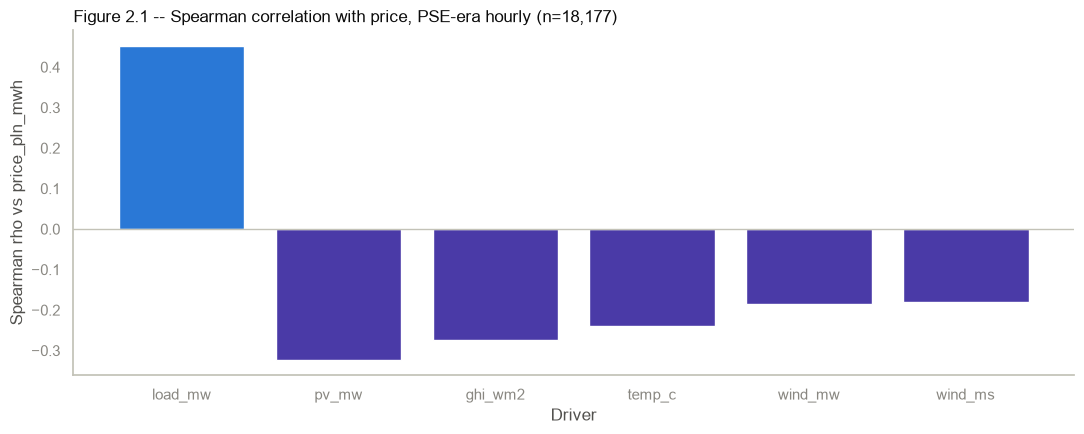

In [5]:
fig, ax = plt.subplots(figsize=FIGSIZE_WIDE)
colors = [BLUE if r > 0 else VIOLET for r in spearman_df["rho"]]
ax.bar(spearman_df["driver"], spearman_df["rho"], color=colors)
ax.axhline(0, color=BASELINE, lw=1)
ax.set_ylabel("Spearman rho vs price_pln_mwh")
ax.set_xlabel("Driver")
ax.set_title(
    f"Figure 2.1 -- Spearman correlation with price, PSE-era hourly (n={len(corr_df):,})",
    loc="left",
)
sns.despine()
plt.tight_layout()
plt.show()

In [6]:
for _, r in spearman_df.iterrows():
    print(f"{r['driver']:10s} rho={r['rho']:+.3f}  p={r['p_value']:.1e}")

load_mw    rho=+0.452  p=0.0e+00
pv_mw      rho=-0.322  p=0.0e+00
ghi_wm2    rho=-0.273  p=5.1e-309
temp_c     rho=-0.239  p=4.5e-235
wind_mw    rho=-0.186  p=2.0e-140
wind_ms    rho=-0.180  p=5.4e-132


Load is the strongest single driver: rho=+0.452 (more demand, higher price,
as expected). Every weather/renewables variable pushes the other way, with
`pv_mw` the strongest of them at rho=-0.322, followed by `ghi_wm2`
(rho=-0.273), `temp_c` (rho=-0.239), `wind_mw` (rho=-0.186) and `wind_ms`
(rho=-0.180). All six are statistically significant at p<0.001 (several
underflow float64 to effectively 0).

**Correlation is not causation here.** Load, weather, and renewable output
all move together -- load itself is weather-driven (heating/cooling demand),
and solar/wind output is weather-driven by construction -- so these rank
correlations mix several channels rather than isolating any one of them.
Section 3 tries to isolate the renewables channel specifically by holding
load fixed in a regression.

## 3. The merit-order effect, quantified

The merit-order story: as renewable output covers a bigger share of load,
cheaper (zero marginal cost) generation displaces expensive marginal units,
pushing the clearing price down. `res_share` here is
`(wind_mw + pv_mw) / load_mw`.

In [7]:
res_df = df.dropna(subset=["price_pln_mwh", "load_mw", "wind_mw", "pv_mw"]).copy()
res_df["res_mw"] = res_df["wind_mw"] + res_df["pv_mw"]
res_df["res_share"] = res_df["res_mw"] / res_df["load_mw"]
res_df["res_share"].describe()

count   18,179.00
mean         0.26
std          0.18
min          0.00
25%          0.11
50%          0.22
75%          0.39
max          0.85
Name: res_share, dtype: float64

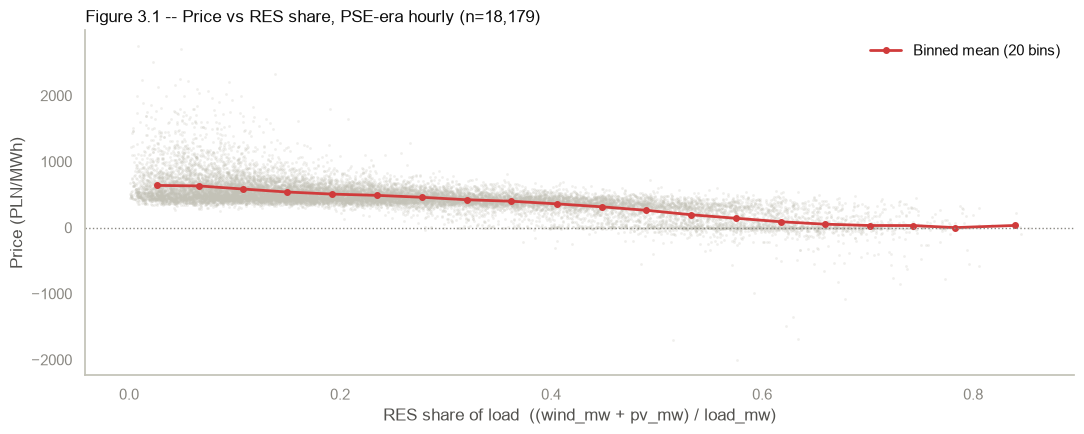

In [8]:
n_bins = 20
res_df["res_share_bin"] = pd.cut(res_df["res_share"], bins=n_bins)
binned = (
    res_df.groupby("res_share_bin", observed=True)
    .agg(
        res_share_mid=("res_share", "mean"),
        price_mean=("price_pln_mwh", "mean"),
        n=("price_pln_mwh", "size"),
    )
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=FIGSIZE_WIDE)
ax.scatter(
    res_df["res_share"], res_df["price_pln_mwh"], s=4, color=BASELINE, alpha=0.25, linewidths=0
)
ax.plot(
    binned["res_share_mid"],
    binned["price_mean"],
    color=RED,
    lw=2,
    marker="o",
    ms=4,
    label=f"Binned mean ({n_bins} bins)",
)
ax.axhline(0, color=INK_MUTED, lw=1, ls=":")
ax.set_xlabel("RES share of load  ((wind_mw + pv_mw) / load_mw)")
ax.set_ylabel("Price (PLN/MWh)")
ax.set_title(f"Figure 3.1 -- Price vs RES share, PSE-era hourly (n={len(res_df):,})", loc="left")
ax.legend(frameon=False, loc="upper right")
sns.despine()
plt.tight_layout()
plt.show()

In [9]:
lowest_bin = binned.iloc[0]
highest_bin = binned[binned["n"] >= 30].iloc[-1]
print(
    f"Lowest RES-share bin (share~{lowest_bin['res_share_mid']:.2f}, n={int(lowest_bin['n']):,}): "
    f"mean price {lowest_bin['price_mean']:,.1f} PLN/MWh"
)
print(
    f"Highest well-populated RES-share bin (share~{highest_bin['res_share_mid']:.2f}, "
    f"n={int(highest_bin['n']):,}): mean price {highest_bin['price_mean']:,.1f} PLN/MWh"
)

Lowest RES-share bin (share~0.03, n=1,237): mean price 639.0 PLN/MWh
Highest well-populated RES-share bin (share~0.78, n=47): mean price 0.1 PLN/MWh


The binned means fall almost monotonically across the whole range: the
lowest RES-share bin (share ~0.03) averages 639.0 PLN/MWh, the highest
well-populated bin (share ~0.78, n=47) averages just 0.1 PLN/MWh. The raw
scatter is wide at every share level, though -- season, weather, and fuel
costs all move price too, which is exactly why a bivariate scatter isn't
enough and the next step controls for load explicitly.

In [10]:
X = sm.add_constant(res_df[["res_share", "load_mw"]])
y = res_df["price_pln_mwh"]
ols_model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 168})
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:          price_pln_mwh   R-squared:                       0.583
Model:                            OLS   Adj. R-squared:                  0.583
Method:                 Least Squares   F-statistic:                     633.3
Date:                Sat, 11 Jul 2026   Prob (F-statistic):          1.27e-266
Time:                        14:13:57   Log-Likelihood:            -1.1784e+05
No. Observations:               18179   AIC:                         2.357e+05
Df Residuals:                   18176   BIC:                         2.357e+05
Df Model:                           2                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        137.8974     25.570      5.393      0.0

**Why HAC (Newey-West) standard errors, not the OLS default:** hourly price
is strongly autocorrelated -- Notebook 01 found ACF at a 24h lag around 0.7
and a clearly non-zero 168h (weekly) lag -- so consecutive residuals here
are not independent. Ordinary OLS standard errors assume independent errors
and would understate the true uncertainty; HAC standard errors stay valid
under that autocorrelation. The lag window is set to **168 hours (one
week)**, matching the longest autocorrelation Notebook 01 actually
documented -- a 24-lag window would only span the daily cycle while the
series demonstrably carries a weekly one too. The next cell shows how much
that choice matters for the confidence interval.

In [11]:
# Sensitivity of the CI to the HAC lag-window choice: refit at a daily (24)
# vs weekly (168) window. The point estimate is identical by construction
# (HAC only changes the covariance, not the fit); only the CI width moves.
sens_rows = []
for lags in (24, 168):
    m = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": lags})
    lo, hi = m.conf_int().loc["res_share"]
    sens_rows.append(
        {
            "maxlags": lags,
            "res_share_coef": m.params["res_share"],
            "ci_lo": lo,
            "ci_hi": hi,
            "ci_width": hi - lo,
        }
    )
sensitivity = pd.DataFrame(sens_rows).set_index("maxlags")
width_ratio = sensitivity.loc[168, "ci_width"] / sensitivity.loc[24, "ci_width"]
print(
    f"Widening the HAC window from 24 to 168 lags leaves the coefficient unchanged "
    f"({sensitivity.loc[168, 'res_share_coef']:,.2f}) and widens the 95% CI by "
    f"{(width_ratio - 1) * 100:.0f}% -- the effect stays large, negative, and "
    "significant under either window, so the conclusion is robust to this choice."
)
sensitivity

Widening the HAC window from 24 to 168 lags leaves the coefficient unchanged (-852.37) and widens the 95% CI by 54% -- the effect stays large, negative, and significant under either window, so the conclusion is robust to this choice.


,res_share_coef,ci_lo,ci_hi,ci_width
maxlags,,,,
24,-852.37,-883.01,-821.74,61.28
168,-852.37,-899.46,-805.29,94.17


In [12]:
coef = ols_model.params["res_share"]
ci_lo, ci_hi = ols_model.conf_int().loc["res_share"]
per10 = coef * 0.10
ci10_lo, ci10_hi = ci_lo * 0.10, ci_hi * 0.10
dw = sm.stats.stattools.durbin_watson(ols_model.resid)
share_load_corr = res_df["res_share"].corr(res_df["load_mw"])

print(
    f"res_share coefficient: {coef:,.1f} PLN/MWh per unit share "
    f"(95% CI {ci_lo:,.1f} to {ci_hi:,.1f})."
)
print(
    f"Each +10pp RES share -> {per10:,.1f} PLN/MWh "
    f"(95% CI {ci10_lo:,.1f} to {ci10_hi:,.1f}), holding load fixed."
)
print(
    f"Durbin-Watson on OLS residuals: {dw:.3f} (well below 2 -> strong positive "
    "autocorrelation, confirming HAC/Newey-West SEs were the right call above)."
)
print(
    f"Correlation between res_share and load_mw: {share_load_corr:+.3f} (near zero -- the "
    "large condition number statsmodels reports above is a units-scale artifact between a "
    "0-1 share and load_mw in thousands, not real multicollinearity)."
)

res_share coefficient: -852.4 PLN/MWh per unit share (95% CI -899.5 to -805.3).
Each +10pp RES share -> -85.2 PLN/MWh (95% CI -89.9 to -80.5), holding load fixed.
Durbin-Watson on OLS residuals: 0.395 (well below 2 -> strong positive autocorrelation, confirming HAC/Newey-West SEs were the right call above).
Correlation between res_share and load_mw: -0.074 (near zero -- the large condition number statsmodels reports above is a units-scale artifact between a 0-1 share and load_mw in thousands, not real multicollinearity).


**Each +10 percentage point increase in RES share is associated with
roughly -85.2 PLN/MWh (95% CI -89.9 to -80.5), holding load fixed.**

That's the merit-order effect, isolated from the load channel and with
uncertainty that's honest about the series' autocorrelation. The
sensitivity check above shows the estimate is robust to the HAC window
choice: a daily (24-lag) window gives the same -85.2 with a tighter CI of
-88.3 to -82.2, so nothing about the conclusion hinges on the window --
the weekly window is simply the more defensible one given the documented
168h autocorrelation, and it's the one reported here. Two caveats worth
stating plainly: this is a 2-regressor model (`res_share` + `load_mw`)
that doesn't control for season or fuel costs, so treat the exact
coefficient as descriptive rather than a precise causal elasticity -- and
the Durbin-Watson statistic of 0.395 shows the residuals are still
autocorrelated even after HAC-correcting the standard errors, which is
exactly why HAC (not vanilla OLS) was used to report the confidence interval
in the first place. The mechanism itself -- cheap renewables displacing
expensive marginal generation -- is physically well understood; the number
above is this dataset's estimate of its size.

## 4. Generation stack vs price

Two real windows, picked by query rather than by eye: the winter week (Dec/
Jan/Feb) with the highest mean price, and the summer (Jun/Jul/Aug) Saturday+
Sunday weekend with the most negative-price hours.

In [13]:
winter = df[df["month_local"].isin([12, 1, 2])].copy()
winter["week_local"] = winter["ts_local"].dt.tz_localize(None).dt.to_period("W")
# Same completeness guard as the summer-weekend pick below: only full
# 168-hour weeks compete, so a partial week at a data boundary can't win
# on a handful of extreme hours.
week_hours = winter.groupby("week_local")["price_pln_mwh"].size()
complete_weeks = week_hours[week_hours >= 168].index
week_price = (
    winter[winter["week_local"].isin(complete_weeks)]
    .groupby("week_local")["price_pln_mwh"]
    .mean()
    .sort_values(ascending=False)
)
chosen_week = week_price.index[0]
winter_window = winter[winter["week_local"] == chosen_week].sort_values("ts_local")

print(
    f"Winter week selected: {winter_window['ts_local'].min():%Y-%m-%d} to "
    f"{winter_window['ts_local'].max():%Y-%m-%d} local ({len(winter_window)} hours), "
    f"mean price {week_price.iloc[0]:,.1f} PLN/MWh, "
    f"peak {winter_window['price_pln_mwh'].max():,.1f} PLN/MWh."
)

Winter week selected: 2026-01-12 to 2026-01-18 local (168 hours), mean price 714.8 PLN/MWh, peak 2,157.6 PLN/MWh.


In [14]:
summer = df[df["month_local"].isin([6, 7, 8])].copy()
summer["date_local"] = summer["ts_local"].dt.date
saturdays = sorted(summer.loc[summer["dow_local"] == 5, "date_local"].unique())

weekend_rows = []
for sat in saturdays:
    sun = sat + pd.Timedelta(days=1)
    sub = summer.loc[summer["date_local"].isin([sat, sun])]
    if len(sub) < 48:
        continue
    weekend_rows.append(
        {
            "sat_date": sat,
            "mean_price": sub["price_pln_mwh"].mean(),
            "min_price": sub["price_pln_mwh"].min(),
            "negative_hours": int((sub["price_pln_mwh"] < 0).sum()),
        }
    )
weekend_summary = pd.DataFrame(weekend_rows).sort_values("negative_hours", ascending=False)
chosen = weekend_summary.iloc[0]
chosen_sat, chosen_sun = chosen["sat_date"], chosen["sat_date"] + pd.Timedelta(days=1)
summer_window = df[
    (df["ts_local"].dt.date >= chosen_sat) & (df["ts_local"].dt.date <= chosen_sun)
].sort_values("ts_local")

print(
    f"Negative-price summer weekend selected: {chosen_sat} to {chosen_sun} local "
    f"({int(chosen['negative_hours'])} negative-price hours out of {len(summer_window)}, "
    f"min {chosen['min_price']:,.1f} PLN/MWh)."
)

Negative-price summer weekend selected: 2024-08-10 to 2024-08-11 local (17 negative-price hours out of 48, min -265.1 PLN/MWh).


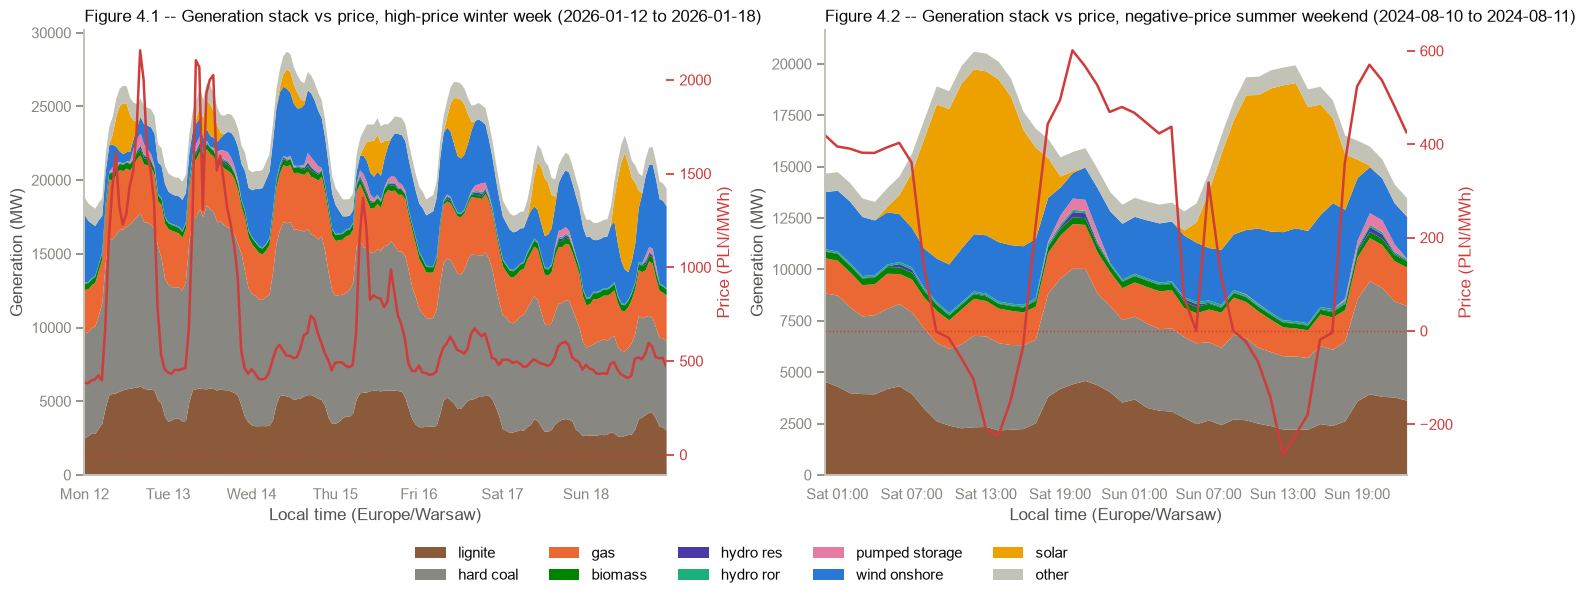

In [15]:
FUEL_ORDER = [
    "gen_lignite",
    "gen_hard_coal",
    "gen_gas",
    "gen_biomass",
    "gen_hydro_res",
    "gen_hydro_ror",
    "gen_pumped_storage",
    "gen_wind_onshore",
    "gen_solar",
    "gen_other",
]
FUEL_LABELS = {c: c.removeprefix("gen_").replace("_", " ") for c in FUEL_ORDER}
FUEL_COLORS = {
    "gen_lignite": BROWN,
    "gen_hard_coal": INK_MUTED,
    "gen_gas": ORANGE,
    "gen_biomass": GREEN,
    "gen_hydro_res": VIOLET,
    "gen_hydro_ror": AQUA,
    "gen_pumped_storage": MAGENTA,
    "gen_wind_onshore": BLUE,
    "gen_solar": AMBER,
    "gen_other": BASELINE,
}
WARSAW = winter_window["ts_local"].dt.tz


def _stack_panel(ax, window, title):
    ax.stackplot(
        window["ts_local"],
        *[window[c] for c in FUEL_ORDER],
        colors=[FUEL_COLORS[c] for c in FUEL_ORDER],
        labels=[FUEL_LABELS[c] for c in FUEL_ORDER],
        linewidth=0,
    )
    ax.set_xlim(window["ts_local"].min(), window["ts_local"].max())
    ax.set_ylabel("Generation (MW)")
    ax.set_title(title, loc="left")
    ax_price = ax.twinx()
    ax_price.plot(window["ts_local"], window["price_pln_mwh"], color=RED, lw=1.8)
    ax_price.axhline(0, color=RED, ls=":", lw=1)
    ax_price.set_ylabel("Price (PLN/MWh)", color=RED)
    ax_price.tick_params(axis="y", colors=RED)
    return ax_price


fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
_stack_panel(
    axes[0],
    winter_window,
    f"Figure 4.1 -- Generation stack vs price, high-price winter week "
    f"({winter_window['ts_local'].min():%Y-%m-%d} to {winter_window['ts_local'].max():%Y-%m-%d})",
)
_stack_panel(
    axes[1],
    summer_window,
    f"Figure 4.2 -- Generation stack vs price, negative-price summer weekend "
    f"({chosen_sat} to {chosen_sun})",
)
axes[0].xaxis.set_major_locator(mdates.DayLocator(tz=WARSAW))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%a %d", tz=WARSAW))
axes[1].xaxis.set_major_locator(mdates.HourLocator(interval=6, tz=WARSAW))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%a %H:%M", tz=WARSAW))
for ax in axes:
    ax.set_xlabel("Local time (Europe/Warsaw)")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=5, frameon=False, bbox_to_anchor=(0.5, -0.1))
sns.despine()
plt.tight_layout()
plt.show()

The two windows make the merit-order mechanism visible, not just
statistical. In the winter week, hard coal alone covers roughly half the
stack around the clock, wind is the only meaningful renewable contributor,
and price tracks demand ramps closely, spiking above 2,000 PLN/MWh on the
coldest evenings. In the summer weekend, solar swells to fill a third or
more of the stack around midday both days -- and each solar bulge lines up
almost exactly with a price crash through zero into negative territory,
recovering as solar fades in the evening. That's the merit-order effect
from Section 3, playing out hour by hour in a single fuel-mix chart.

## 5. Weather -> power: the physical link

Section 2's weather-vs-price correlations were loose (rho around -0.2 to
-0.3) because price is an economic outcome with many confounds. The
weather-to-*generation* link, by contrast, is a physical one: wind speed
drives turbine output and irradiance drives panel output almost
deterministically, modulo turbine/panel capacity and siting. We check that
directly against `drivers_frame()`'s pivoted fuel-mix columns,
`gen_wind_onshore` and `gen_solar`.

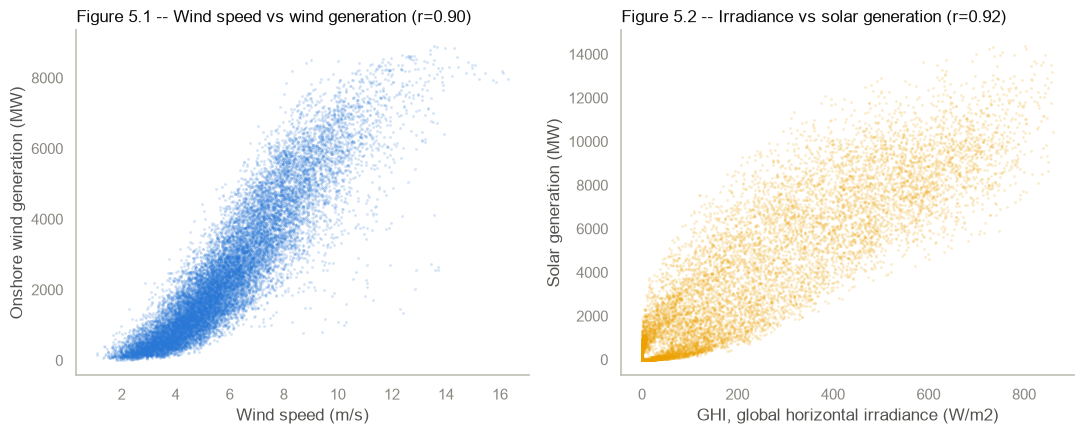

Pearson r, wind_ms vs gen_wind_onshore: 0.905 (p=0.0e+00)
Pearson r, ghi_wm2 vs gen_solar: 0.924 (p=0.0e+00)


In [16]:
phys = df.dropna(subset=["wind_ms", "gen_wind_onshore", "ghi_wm2", "gen_solar"])
r_wind, p_wind = pearsonr(phys["wind_ms"], phys["gen_wind_onshore"])
r_solar, p_solar = pearsonr(phys["ghi_wm2"], phys["gen_solar"])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].scatter(phys["wind_ms"], phys["gen_wind_onshore"], s=4, color=BLUE, alpha=0.2, linewidths=0)
axes[0].set_xlabel("Wind speed (m/s)")
axes[0].set_ylabel("Onshore wind generation (MW)")
axes[0].set_title(f"Figure 5.1 -- Wind speed vs wind generation (r={r_wind:.2f})", loc="left")

axes[1].scatter(phys["ghi_wm2"], phys["gen_solar"], s=4, color=AMBER, alpha=0.2, linewidths=0)
axes[1].set_xlabel("GHI, global horizontal irradiance (W/m2)")
axes[1].set_ylabel("Solar generation (MW)")
axes[1].set_title(f"Figure 5.2 -- Irradiance vs solar generation (r={r_solar:.2f})", loc="left")

sns.despine()
plt.tight_layout()
plt.show()

print(f"Pearson r, wind_ms vs gen_wind_onshore: {r_wind:.3f} (p={p_wind:.1e})")
print(f"Pearson r, ghi_wm2 vs gen_solar: {r_solar:.3f} (p={p_solar:.1e})")

In [17]:
xcheck = df.dropna(subset=["wind_mw", "gen_wind_onshore", "pv_mw", "gen_solar"])
r_wind_cross = xcheck["wind_mw"].corr(xcheck["gen_wind_onshore"])
r_pv_cross = xcheck["pv_mw"].corr(xcheck["gen_solar"])
max_wind_gap = (xcheck["wind_mw"] - xcheck["gen_wind_onshore"]).abs().max()
max_pv_gap = (xcheck["pv_mw"] - xcheck["gen_solar"]).abs().max()
print(
    f"Cross-check, res_hourly vs gen_mix_hourly: "
    f"wind_mw vs gen_wind_onshore r={r_wind_cross:.6f} (max gap {max_wind_gap:.1f} MW); "
    f"pv_mw vs gen_solar r={r_pv_cross:.6f} (max gap {max_pv_gap:.1f} MW)."
)

Cross-check, res_hourly vs gen_mix_hourly: wind_mw vs gen_wind_onshore r=1.000000 (max gap 31.8 MW); pv_mw vs gen_solar r=1.000000 (max gap 48.0 MW).


Both physical relationships are strong: r=0.90 for wind speed against
onshore-wind output, r=0.92 for irradiance against solar output -- far
tighter than any weather-price correlation in Section 2, exactly as
expected for a physical process versus an economic one.

**Curtailment caveat:** the brief for this section asked whether curtailment
is visible by comparing the fuel-mix generation columns against
`res_hourly`'s `wind_mw`/`pv_mw`. It isn't, here -- `wind_mw` tracks
`gen_wind_onshore` at r=1.000000 to six decimal places (max gap ~32 MW
against a series running into the thousands) and `pv_mw` tracks `gen_solar`
just as tightly. The two
columns are evidently two measurements of the same underlying metered
output rather than independent signals of *available* vs. *dispatched*
generation, so this dataset can't distinguish "wind was calm" from "wind was
curtailed" -- that would need a capacity or availability series this
warehouse doesn't have. Recorded here as an honest gap rather than a
curtailment story the data doesn't support.

## 6. Cross-source QA

Notebook 01 introduced the two-source price series (Ember pre-PSE, PSE
CSDAC after). `marts.qa_overlap` independently re-derives Ember's PLN price
(`price_eur_mwh * eur_pln`, the daily NBP mid fixing) and compares it
hour-by-hour against PSE's own PLN price over their full overlap -- a
built-in consistency check on the price series everything above is built
on.

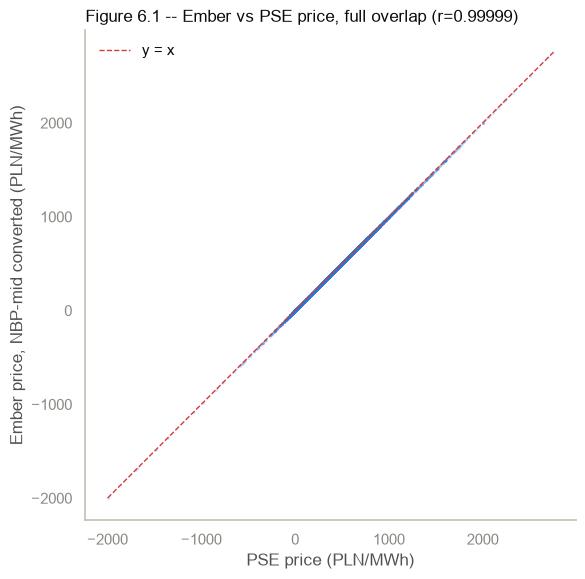

In [18]:
qa = analysis.load_table("marts.qa_overlap")
r_qa = qa["ember_pln"].corr(qa["pse_pln"])

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(qa["pse_pln"], qa["ember_pln"], s=4, color=BLUE, alpha=0.2, linewidths=0)
lims = [qa[["pse_pln", "ember_pln"]].min().min(), qa[["pse_pln", "ember_pln"]].max().max()]
ax.plot(lims, lims, color=RED, ls="--", lw=1, label="y = x")
ax.set_xlabel("PSE price (PLN/MWh)")
ax.set_ylabel("Ember price, NBP-mid converted (PLN/MWh)")
ax.set_title(f"Figure 6.1 -- Ember vs PSE price, full overlap (r={r_qa:.5f})", loc="left")
ax.legend(frameon=False, loc="upper left")
ax.set_aspect("equal")
sns.despine()
plt.tight_layout()
plt.show()

In [19]:
median_abs_diff = qa["abs_diff"].median()
nonzero = qa["pse_pln"] != 0  # a handful of exact-zero-price hours would divide by zero
rel_diff_pct = qa.loc[nonzero, "abs_diff"] / qa.loc[nonzero, "pse_pln"].abs() * 100
median_rel_diff_pct = rel_diff_pct.median()
gap_vs_level_corr = qa["abs_diff"].corr(qa["pse_pln"].abs())

print(f"{len(qa):,} overlapping hours, Pearson r={r_qa:.5f}.")
print(
    f"Median abs diff: {median_abs_diff:.2f} PLN/MWh ({median_rel_diff_pct:.3f}% of price level, "
    f"n={int(nonzero.sum()):,} hours with nonzero PSE price)."
)
print(f"Max abs diff: {qa['abs_diff'].max():.2f} PLN/MWh.")
print(f"Correlation between abs_diff and |pse_pln| (price level): {gap_vs_level_corr:.3f}.")

18,166 overlapping hours, Pearson r=0.99999.
Median abs diff: 0.19 PLN/MWh (0.060% of price level, n=18,099 hours with nonzero PSE price).
Max abs diff: 14.38 PLN/MWh.
Correlation between abs_diff and |pse_pln| (price level): 0.412.


In [20]:
top10 = qa.sort_values("abs_diff", ascending=False).head(10)
median_price_level = qa["pse_pln"].abs().median()
print(
    f"Overall median |price|: {median_price_level:,.0f} PLN/MWh. "
    f"Median |price| among the 10 largest gaps: {top10['pse_pln'].abs().median():,.0f} PLN/MWh."
)
top10[["ts_utc", "ember_pln", "pse_pln", "abs_diff"]]

Overall median |price|: 450 PLN/MWh. Median |price| among the 10 largest gaps: 1,102 PLN/MWh.


,ts_utc,ember_pln,pse_pln,abs_diff
15875,2024-07-17 18:00:00,"2,056.99","2,042.61",14.38
3444,2024-07-17 19:00:00,"1,811.45","1,798.78",12.67
4508,2024-07-17 17:00:00,"1,749.07","1,736.84",12.23
1598,2025-04-04 05:00:00,770.00,758.88,11.12
8065,2024-11-12 16:00:00,"1,438.99","1,428.22",10.77
16257,2025-04-04 17:00:00,732.47,721.90,10.57
11746,2025-04-07 05:00:00,785.71,775.25,10.46
2742,2025-04-07 17:00:00,769.25,759.01,10.24
9455,2025-04-07 18:00:00,764.91,754.73,10.18
19,2024-06-25 18:00:00,"1,510.61","1,520.79",10.18


The two sources agree almost perfectly: r=0.99999 across 18,166 overlapping
hours, with a median gap of 0.19 PLN/MWh -- about 0.06% of the price level.
That residual is not noise; it scales with the price level itself
(correlation 0.412 between the gap and |price|, and the 10 largest gaps in
the table sit at a median |price| several times the series' overall median
-- see the table above), which is exactly the fingerprint of a
small, roughly proportional FX/rounding mismatch rather than a genuine
disagreement about the price. `marts.qa_overlap` converts Ember's EUR/MWh
series using NBP's single official daily mid-point fixing, while Poland's
actual day-ahead market coupling (run under SDAC) clears and settles using
its own coupling-specific EUR/PLN conversion at a different point in the
day. A daily FX rate applied to an hourly price series will never match a
market-native currency price exactly, and that's the honest source of this
gap -- not a defect in either price series, and not something worth
"fixing" by picking one FX convention as more correct than the other.

## 7. Takeaways

Five findings, each backed by a number computed above.

In [21]:
finding_1 = (
    "1. Load is the strongest single rank-correlate of price (Spearman rho=+0.45); "
    "renewables push the other way, led by pv_mw (rho=-0.32) -- but these are just "
    "monotonic associations: load, weather, and RES output all move together, so none "
    "of the six is isolated from the others here."
)
finding_2 = (
    "2. Isolating the renewables channel via OLS (price on res_share + load_mw, HAC/"
    "Newey-West SEs at a 168h lag window, matching the weekly autocorrelation the "
    f"hourly series carries): each +10pp of RES share in load is associated with "
    f"{per10:,.1f} PLN/MWh (95% CI {ci10_lo:,.1f} to {ci10_hi:,.1f}), holding load "
    "fixed -- robust to a daily (24-lag) window, which leaves the estimate unchanged "
    "and only tightens the CI."
)
finding_3 = (
    "3. The mechanism is visible hour by hour: the highest-price winter week in the "
    f"data ({winter_window['ts_local'].min():%Y-%m-%d} to "
    f"{winter_window['ts_local'].max():%Y-%m-%d}) "
    f"averaged {week_price.iloc[0]:,.0f} PLN/MWh on a coal-heavy stack, while the most "
    f"negative-price summer weekend ({chosen_sat} to {chosen_sun}) saw solar reach "
    f"{summer_window['gen_solar'].max():,.0f} MW and price fall to {chosen['min_price']:,.0f} "
    f"PLN/MWh across {int(chosen['negative_hours'])} negative hours."
)
finding_4 = (
    f"4. Weather maps far more tightly onto generation than onto price: wind speed vs "
    f"onshore-wind output correlates at r={r_wind:.2f} and irradiance vs solar output at "
    f"r={r_solar:.2f} (a physical, near-deterministic link), versus rho=-0.18/-0.27 for the "
    "same two weather variables against price (an economic outcome with many confounds)."
)
finding_5 = (
    f"5. The price series itself checks out across sources: marts.qa_overlap finds "
    f"Ember and PSE agree at r={r_qa:.5f} over {len(qa):,} overlapping hours, median gap "
    f"{median_abs_diff:.2f} PLN/MWh ({median_rel_diff_pct:.2f}% of price level) -- a residual "
    "that scales with price level, consistent with the two sources' different EUR/PLN "
    "conversion conventions rather than a real price disagreement."
)
print(finding_1)
print(finding_2)
print(finding_3)
print(finding_4)
print(finding_5)

1. Load is the strongest single rank-correlate of price (Spearman rho=+0.45); renewables push the other way, led by pv_mw (rho=-0.32) -- but these are just monotonic associations: load, weather, and RES output all move together, so none of the six is isolated from the others here.
2. Isolating the renewables channel via OLS (price on res_share + load_mw, HAC/Newey-West SEs at a 168h lag window, matching the weekly autocorrelation the hourly series carries): each +10pp of RES share in load is associated with -85.2 PLN/MWh (95% CI -89.9 to -80.5), holding load fixed -- robust to a daily (24-lag) window, which leaves the estimate unchanged and only tightens the CI.
3. The mechanism is visible hour by hour: the highest-price winter week in the data (2026-01-12 to 2026-01-18) averaged 715 PLN/MWh on a coal-heavy stack, while the most negative-price summer weekend (2024-08-10 to 2024-08-11) saw solar reach 8,030 MW and price fall to -265 PLN/MWh across 17 negative hours.
4. Weather maps far 